# Tutorial study on BlueSky

Due to online  [tutorial](https://blueskyproject.io/bluesky/tutorial.html).

In [1]:
import bluesky

print(f'Import BlueSky V{bluesky.__version__}')

Import BlueSky V1.11.0


## 1. Preparation

- Run engine
- Live visualization
- Storage
- Progress bar

In [2]:
RE = bluesky.RunEngine({})
print(f'Create Run Engine: {RE}')

Create Run Engine: <bluesky.run_engine.RunEngine object at 0x000002721F0755D0>


In [3]:
from bluesky.callbacks.best_effort import BestEffortCallback

bec = BestEffortCallback()
RE.subscribe(bec)
print(f'Use {bec} to receive metadata and data in real time')

Use <bluesky.callbacks.best_effort.BestEffortCallback object at 0x00000272771BF3D0> to receive metadata and data in real time


In [4]:
from databroker import Broker

db = Broker.named('temp')
RE.subscribe(db.insert)
print(f'Use {db} as storage of metadata and data')

Use <databroker.v1.Broker object at 0x00000272771BF7F0> as storage of metadata and data


In [5]:
progress = bluesky.utils.ProgressBarManager()
RE.waiting_hook = progress
print(f'Prepare progress bar manager: {progress}')

Prepare progress bar manager: <bluesky.utils.ProgressBarManager object at 0x000002721FD2F640>


## 2. Demo based on simulated devices

In [6]:
import ophyd

help(ophyd.device.Device)

Help on class Device in module ophyd.device:

class Device(BlueskyInterface, ophyd.ophydobj.OphydObject)
 |  Device(prefix='', *, name, kind=None, read_attrs=None, configuration_attrs=None, parent=None, **kwargs)
 |  
 |  Base class for device objects
 |  
 |  This class provides attribute access to one or more Signals, which can be
 |  a mixture of read-only and writable. All must share the same base_name.
 |  
 |  Parameters
 |  ----------
 |  prefix : str, optional
 |      The PV prefix for all components of the device
 |  name : str, keyword only
 |      The name of the device (as will be reported via read()`
 |  kind : a member of the :class:`~ophydobj.Kind` :class:`~enum.IntEnum`
 |      (or equivalent integer), optional
 |      Default is ``Kind.normal``. See :class:`~ophydobj.Kind` for options.
 |  read_attrs : sequence of attribute names
 |      DEPRECATED: the components to include in a normal reading
 |      (i.e., in ``read()``)
 |  configuration_attrs : sequence of attribu

In [7]:
from ophyd.sim import det1, det2, motor, det

detects = [det1, det2]

print('Simulated detector')
print('------------------')
det.summary()
print()

print('Simulated motor')
print('---------------')
motor.summary()
print()

Simulated detector
------------------
data keys (* hints)
-------------------
*det

read attrs
----------
val                  SynSignal           ('det')

config keys
-----------
det_Imax
det_center
det_noise
det_noise_multiplier
det_sigma

configuration attrs
-------------------
Imax                 Signal              ('det_Imax')
center               Signal              ('det_center')
sigma                Signal              ('det_sigma')
noise                EnumSignal          ('det_noise')
noise_multiplier     Signal              ('det_noise_multiplier')

unused attrs
------------


Simulated motor
---------------
data keys (* hints)
-------------------
*motor
 motor_setpoint

read attrs
----------
readback             _ReadbackSignal     ('motor')
setpoint             _SetpointSignal     ('motor_setpoint')

config keys
-----------
motor_acceleration
motor_velocity

configuration attrs
-------------------
velocity             Signal              ('motor_velocity')
acceleration  

### 2.1 counting

In [8]:
from bluesky.plans import count

task01 = count([det1, det2], 5)
print(f'Generate counting task {task01}')

Generate counting task <generator object count at 0x000002724F595380>




Transient Scan ID: 1     Time: 2023-08-24 15:29:36
Persistent Unique Scan ID: '5dacdef8-4365-4e0c-83fd-d36fe1185148'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |       det1 |       det2 |
+-----------+------------+------------+------------+
|         1 | 15:29:36.2 |      5.000 |      1.765 |
|         2 | 15:29:36.3 |      5.000 |      1.765 |
|         3 | 15:29:36.3 |      5.000 |      1.765 |
|         4 | 15:29:36.4 |      5.000 |      1.765 |
|         5 | 15:29:36.5 |      5.000 |      1.765 |
+-----------+------------+------------+------------+
generator count ['5dacdef8'] (scan num: 1)





('5dacdef8-4365-4e0c-83fd-d36fe1185148',)

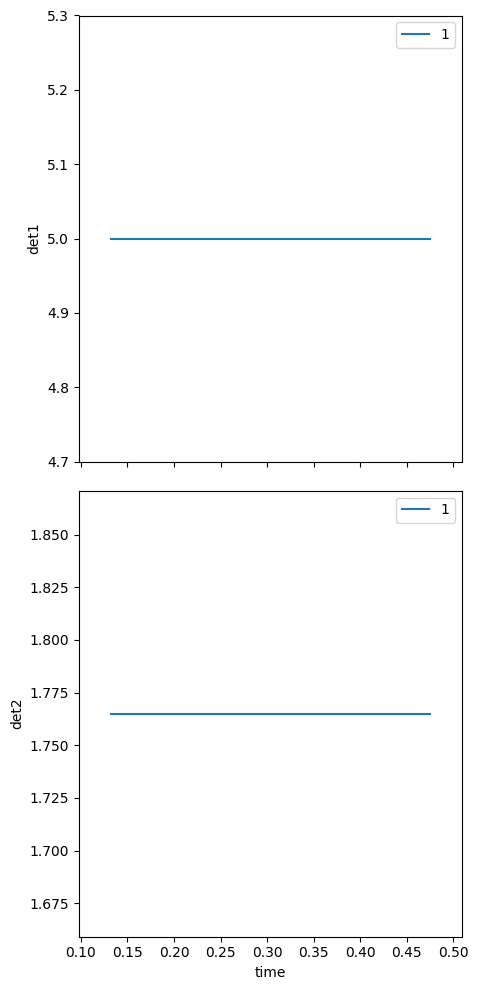

In [9]:
RE(task01)

### 2.2 scanning motor and detect

In [10]:
from bluesky.plans import scan

task02 = scan([det], motor, -1, 1, 11)
print(f'Generate scanning task {task02}')

Generate scanning task <generator object scan at 0x000002724F595620>




Transient Scan ID: 2     Time: 2023-08-24 15:29:37
Persistent Unique Scan ID: '30a5b9d7-9081-4082-92c4-d69474a54163'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      motor |        det |
+-----------+------------+------------+------------+
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
 failed to format row 
+-----------+------------+------------+------------+
generator scan ['30a5b9d7'] (scan num: 2)





('30a5b9d7-9081-4082-92c4-d69474a54163',)

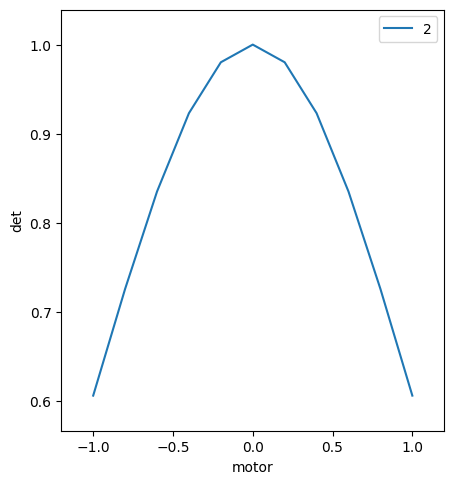

In [11]:
RE(task02)



Transient Scan ID: 3     Time: 2023-08-24 15:29:37
Persistent Unique Scan ID: 'dde782f4-731a-4788-9d98-c0fb548589af'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      motor |        det |
+-----------+------------+------------+------------+
|         1 | 15:29:37.6 |     -2.000 |      0.135 |
|         2 | 15:29:37.7 |     -1.800 |      0.198 |
|         3 | 15:29:37.7 |     -1.600 |      0.278 |
|         4 | 15:29:37.7 |     -1.400 |      0.375 |
|         5 | 15:29:37.7 |     -1.200 |      0.487 |
|         6 | 15:29:37.8 |     -1.000 |      0.607 |
|         7 | 15:29:37.8 |     -0.800 |      0.726 |
|         8 | 15:29:37.8 |     -0.600 |      0.835 |
|         9 | 15:29:37.9 |     -0.400 |      0.923 |
|        10 | 15:29:37.9 |     -0.200 |      0.980 |
|        11 | 15:29:37.9 |      0.000 |      1.000 |
+-----------+------------+------------+------------+
generator rel_scan ['dde782f4'] (scan num: 3)





('dde782f4-731a-4788-9d98-c0fb548589af',)

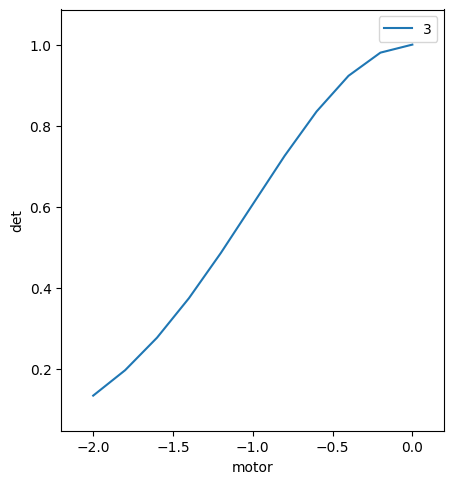

In [12]:
from bluesky.plans import rel_scan

motor.set(-1.0)
RE(rel_scan([det], motor, -1, 1, 11))



Transient Scan ID: 4     Time: 2023-08-24 15:29:38
Persistent Unique Scan ID: '48ebb9a8-152f-492a-8759-af1caf7c1168'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |      motor |        det |
+-----------+------------+------------+------------+
|         1 | 15:29:38.2 |      0.100 |      0.995 |
|         2 | 15:29:38.3 |      0.500 |      0.882 |
|         3 | 15:29:38.3 |      1.500 |      0.325 |
|         4 | 15:29:38.3 |     -1.000 |      0.607 |
+-----------+------------+------------+------------+
generator list_scan ['48ebb9a8'] (scan num: 4)





('48ebb9a8-152f-492a-8759-af1caf7c1168',)

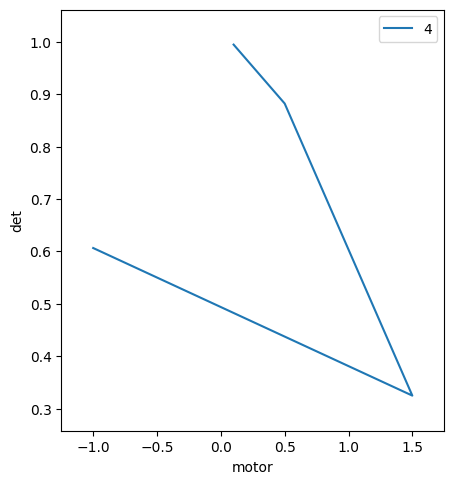

In [13]:
from bluesky.plans import list_scan

RE(list_scan([det], motor, [0.1, 0.5, 1.5, -1.0]))

### 2.3 grid scanning

In [14]:
from ophyd.sim import det4, motor1, motor2

In [18]:
from bluesky.plans import grid_scan

task03 = grid_scan([det4], motor1, -1.5, 1.5, 3, motor2, -0.2, 1.0, 5)



Transient Scan ID: 6     Time: 2023-08-24 15:30:09
Persistent Unique Scan ID: '476707d0-0229-4e93-a65a-90c3ff123917'
New stream: 'primary'
+-----------+------------+------------+------------+------------+
|   seq_num |       time |     motor1 |     motor2 |       det4 |
+-----------+------------+------------+------------+------------+
|         1 | 15:30:09.2 |     -1.500 |     -0.200 |      0.318 |
|         2 | 15:30:09.2 |     -1.500 |      0.100 |      0.323 |
|         3 | 15:30:09.3 |     -1.500 |      0.400 |      0.300 |
|         4 | 15:30:09.3 |     -1.500 |      0.700 |      0.254 |
|         5 | 15:30:09.4 |     -1.500 |      1.000 |      0.197 |
|         6 | 15:30:09.4 |      0.000 |     -0.200 |      0.980 |
|         7 | 15:30:09.5 |      0.000 |      0.100 |      0.995 |
|         8 | 15:30:09.5 |      0.000 |      0.400 |      0.923 |
|         9 | 15:30:09.5 |      0.000 |      0.700 |      0.783 |
|        10 | 15:30:09.6 |      0.000 |      1.000 |      0.607 |
|

('476707d0-0229-4e93-a65a-90c3ff123917',)

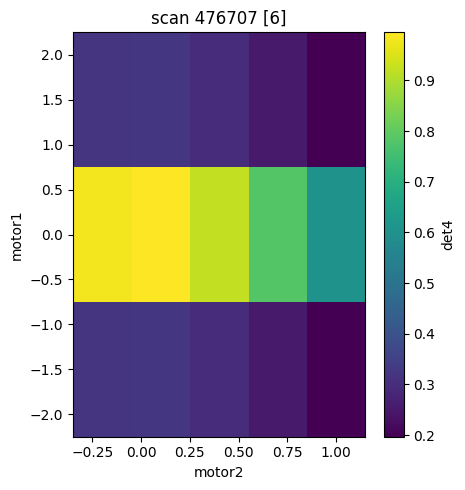

In [19]:
RE(task03)